In [1]:
import sys
sys.path.append('../../utils')
from functions import * 

In [2]:
from importlib import reload
import sys
import scipy as sp
from scipy.special import expit, logit

import matplotlib.pyplot as plt 

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

import  load_cluster_data
reload (load_cluster_data)

from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Some utility functions 


In [4]:
# write function that takes in Cluster name 
def check_SS_cluster(cluster_name):
    
    # this cluster can also be used to label intron clusters as exon inclusion/exclusion event 
    juncs_c = junc_info[junc_info["Cluster"] == cluster_name]
    
    # keep only rows where either start or end appear twice
    s = np.array(juncs_c[juncs_c.duplicated(subset=['start'])].start.unique())
    e = np.array(juncs_c[juncs_c.duplicated(subset=['end'])].end.unique())
    juncs_c = juncs_c[(juncs_c["start"].isin(s)) | (juncs_c["end"].isin(e))]

    # if num rows in juncs_c is 3 then return cluster name 
    if len(juncs_c == 3):
        # confirm cluster has non zero counts in both cell types 
        num_celltypes = len(final_data[final_data.Cluster == cluster_name].cell_type.unique())
        if num_celltypes > 1:
            # confirm that each junction has non zero counts in both cell types
            counts_juncs = final_data[final_data.Cluster == cluster_name].junction_id.value_counts()
            counts_juncs = counts_juncs[counts_juncs > 1]
            num_cells=len(counts_juncs.index.unique())
            if num_cells == 3:
                return cluster_name
    else:
        pass

In [5]:
def simulate_junc_counts_multistate(cluster_counts, junc_info, cell_types=None, psi_prior_shape1=0.5, psi_prior_shape2=0.5):
    
    """Simulate junc counts while keeping the cluster counts of observed data. 
    
    Args: 
        cluster_counts: scipy coo_matrix. 
        cell_types: pandas Categorical series of pre-defined cell types to use for simulations 
        psi_prior_shape1: float.
        psi_prior_shape2: float.
    Returns:
        sim_junc_counts: scipy coo_matrix. 
        cell_type_labels: numpy array of cell type labels. 
        cell_type_psi: numpy array of cell type specific PSI values.
    """
    
    N, P = cluster_counts.shape  # number of cells, number of junctions
     
    # use real cell types labels to represent intron clusters being higher/lower in specific cell types 
    print("Using pre-defined cell types!")
    cell_type_labels = cell_types.cat.codes.to_numpy()
    K = len(cell_types.cat.categories)  # number of cell types
    
    print(N, P, K, len(cell_types))
    
    # number of intron clusters 
    num_clusters = len(junc_info.Cluster.unique())

    # label clusters as positive or negative by sampling 
    cluster_labels = np.random.choice([0, 1], size=num_clusters)

    # make a mapping of Cluster ID to cluster_labels
    cluster_labels_dict = dict(zip(junc_info.Cluster.unique(), cluster_labels))

    # initiate empty dataframe cell_type_psi_df to which we will append the simulated PSI values for each junction in each cell type
    cell_type_psi_df = pd.DataFrame()

    for clust in tqdm(junc_info.Cluster.unique()):
        clust_label = cluster_labels_dict[clust]
        # get cluster label
        # get junctions in cluster and order them by start and end 
        juncs_c = junc_info[junc_info["Cluster"] == clust]
        # order juncs_c by start and end
        juncs_c = juncs_c.sort_values(by=['start', 'end'])
        # assign J1, J2, and J3 to junctions where J1+J2 correspond to exon inclusion and J3 corresponds to exon skipping
        juncs_c["junction"] = ["J1", "J3", "J2"] 
        num_juncs = len(juncs_c)    
        if clust_label == 0: 
            # sample PSI values for each junction in each cell type via pre-defined beta distributions
            probs = torch.distributions.beta.Beta(psi_prior_shape1, psi_prior_shape2).sample([num_juncs, K]) 
            # get J3 prob 
            probs[1,] = probs[1,:]
            probs[0,] = (1-probs[1,1])/2
            probs[2,] = (1-probs[1,1])/2
            # convert probs to dataframe 
            probs_df = pd.DataFrame(probs.numpy())
            # add junction_id_index column to probs_df
            probs_df["new_junction_id_index"] = juncs_c["new_junction_id_index"].values
            probs_df["sample_label"] = "negative"
            probs_df["Cluster"] = juncs_c["Cluster"].values[0]
            # appent probs_df to cell_type_psi_df
            cell_type_psi_df = pd.concat([cell_type_psi_df, probs_df])
        elif clust_label == 1:
            probs = torch.distributions.beta.Beta(psi_prior_shape1, psi_prior_shape2).sample([num_juncs, K]) 
            # get J3 prob
            J3_prob = probs[1,]
            probs[0,] = (1-J3_prob)/2
            probs[2,] = (1-J3_prob)/2
            probs_df = pd.DataFrame(probs.numpy())
            probs_df["new_junction_id_index"] = juncs_c["new_junction_id_index"].values
            probs_df["sample_label"] = "positive"
            probs_df["Cluster"] = juncs_c["Cluster"].values[0]
            # use pd.concat to append probs_df to cell_type_psi_df
            cell_type_psi_df = pd.concat([cell_type_psi_df, probs_df])

    cell_type_psi_df = cell_type_psi_df.sort_values(by=['new_junction_id_index'])
    cell_type_psi = torch.tensor(cell_type_psi_df.iloc[:,0:K+1].to_numpy()) 

    print("Done simulating PSI!")

    # use real cluster counts to simulate junc counts with binomial distribution
    sim_junc_counts = cluster_counts.copy() 
    sim_junc_counts.data = torch.distributions.binomial.Binomial( 
         total_count=torch.tensor(cluster_counts.data), 
         probs=cell_type_psi[
             cluster_counts.col, # junction index
             cell_type_labels[cluster_counts.row] # cell index 
         ]
    ).sample().numpy()
    
    print("Done simulating junc counts!")
    
    return sim_junc_counts, cell_type_labels, cell_type_psi, cell_type_psi_df

In [6]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    sample_label = simple_data_junc.sample_label.unique()[0]

    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title(sample_label + " label for cluster:" + str(clust))
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)")
    plt.show()

In [7]:
def plot_juncProbs(junc_index):
    
    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == junc_index].junction_id.values[0]
    
    # implement utility to visualize full beta distributions for each junction in each cell type
    # using ALPHA_f and PI_f 

    # get data for just junc_index 
    junc_dat = juncs_probs_df[juncs_probs_df.new_junction_id_index == junc_index]
    junc_dat = junc_dat.melt().iloc[0:K]
    junc_dat.value = junc_dat.value.astype(float)
    # make violin plot for junc_dat junction usage ratio coloured by cell_type
    # don't print x-axis tick labels 
    plot = ggplot(junc_dat, aes(x='variable', y='value')) + geom_point() + theme(axis_text_x=element_blank())
    print(plot)

In [8]:
# use sim_dat to get cluster level PSI for each cluster using J1+J2/J3 
def get_cluster_PSI(cluster, sim_data, junc_info):
    # cell clust counts 
    clust_only_counts = sim_data[sim_data["Cluster"] == cluster]

    # junction label info (J1, J2, J3)
    clust_dat = junc_info[junc_info["Cluster"] == cluster]
    clust_dat.sort_values(by = ["start", "end"], inplace = True)
    clust_dat["junc_label"] = ["J1", "J3", "J2"]
    clust_dat = clust_dat[["Cluster", "junc_label", "new_junction_id_index"]]
    # rename new_junction_id_index column to junction_id_index 
    clust_dat.rename(columns = {"new_junction_id_index": "junction_id_index"}, inplace = True)
    clust_only_counts = sim_data[sim_data["Cluster"] == cluster]
    #merge clust_dat with clust_only_counts 
    clust_only_counts = clust_only_counts.merge(clust_dat, on = ["Cluster", "junction_id_index"])
    clust_only_counts = clust_only_counts[["cell_id_index", "Cluster", "junction_id_index", "junc_count", "cluster_count", "junc_label"]]
    clust_only_counts.sort_values(by = ["cell_id_index", "junction_id_index"], inplace = True)
    
    clust_only_counts_mat = clust_only_counts.pivot(index = "junction_id_index", columns = "cell_id_index", values = "junc_count")
    cols_names = list(clust_only_counts_mat)
    clust_only_counts_mat["junc_label"] = clust_only_counts[["junction_id_index", "junc_label"]].drop_duplicates()["junc_label"].values
    # reorder rows using junc_label
    clust_only_counts_mat.sort_values(by = ["junc_label"], inplace = True)
    # for each column calculate J1+J2/J1+J2+J3
    # for each cell in each column sum first two rows and divide by sum of all three rows
    clust_cells_psi = []
    for i in cols_names:
        col_index = clust_only_counts_mat.columns.get_loc(i)
        psi_value = clust_only_counts_mat.iloc[2,col_index].sum() / clust_only_counts_mat.iloc[:,col_index].sum()
        # save cell index (i), cluster and psi value
        clust_cells_psi.append([i, cluster, psi_value])

    # convert clust_cells_psi to dataframe
    clust_cells_psi = pd.DataFrame(clust_cells_psi, columns = ["cell_id_index", "Cluster", "cluster_psi"])
    return(clust_cells_psi)

### Settings and Load data

In [9]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cpu
0.02


### Load data

In [10]:
cell_types = ['Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte',
       'Brain_Non-Myeloid_oligodendrocyte',
       'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_neuron',
       'Brain_Non-Myeloid_oligodendrocyte_precursor_cell',
       'Brain_Non-Myeloid_brain_pericyte', 'Brain_Myeloid_macrophage']
print(cell_types)

['Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_neuron', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_brain_pericyte', 'Brain_Myeloid_macrophage']


In [11]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain_simulation/'

### Convert data to Leaflet required input formats 

In [12]:
# let's start with the set of cell types first 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=7500, celltypes=cell_types) 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain_simulation/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_neuron', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_brain_pericyte', 'Brain_Myeloid_macrophage']
['Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Myeloid_microglial_cell' 'Brain_Myeloid_macrophage'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_astrocyte' 'Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_neuron']
7816
72770
The maximum junction count was initially:  720176
487
The maximum junction count is now:  7486
                                             cell_id  Cluster  Cluster_Counts  \
0  A1-MAA000564-3_10_M-1-1_Brain_Non-Myelo

In [13]:
# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [14]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                     2823
junction_id_index                                                 3689
junc_count                                                        34.0
cluster_count                                                       34
clustminjunc                                                       0.0
juncratio                                                          1.0
cell_id              C10-MAA000617-3_10_M-1-1_Brain_Myeloid_microgl...
cell_type                                Brain_Myeloid_microglial_cell
junction_id                                       11_75752080_75755573
Cluster                                                          13507
Name: 11999739, dtype: object
34.0
34


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [15]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

4202


In [16]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()):
    clusters_SS.append(check_SS_cluster(cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

100%|██████████| 4202/4202 [04:01<00:00, 17.41it/s]

3613


In [17]:
# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

10839


In [18]:
# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

   junction_id_index          junction_id  Cluster  new_junction_id_index
0                  0    1_7089216_7120193       14                      0
1                  1    1_7120615_7147636       14                      1
2                  4    1_7163371_7169514       17                      2
3                 22  1_37890584_37892942       81                      3
4                 23  1_37893023_37893938       81                      4


In [19]:
# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,new_junction_id_index
0,0,0,17.0,22,5.0,0.772727,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,Brain_Non-Myeloid_endothelial_cell,1_7089216_7120193,14,0
819,5993,0,1.0,14,13.0,0.071429,N5-MAA000604-3_10_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0
818,5951,0,8.0,37,29.0,0.216216,N3-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0
817,5942,0,1.0,1,0.0,1.000000,N22-MAA000573-3_9_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0
816,5885,0,21.0,76,55.0,0.276316,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0


In [20]:
to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

In [21]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                         1781
junction_id_index                                                    20825
junc_count                                                             0.0
cluster_count                                                           17
clustminjunc                                                          17.0
juncratio                                                              0.0
cell_id                  K21-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_oli...
cell_type                                Brain_Non-Myeloid_oligodendrocyte
junction_id                                           17_66042601_66049785
Cluster                                                              19766
new_junction_id_index                                                 3609
Name: 3508434, dtype: object
0.0
17


### Simulate Data

In [22]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_7089216_7120193,14,0,1,7089216,7120193,0
1,1_7120615_7147636,14,1,1,7120615,7147636,1
2,1_7163371_7169514,17,4,1,7163371,7169514,2
3,1_37890584_37892942,81,22,1,37890584,37892942,3
4,1_37893023_37893938,81,23,1,37893023,37893938,4


In [23]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = simulate_junc_counts_multistate(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
7816 10839 8 7816


100%|██████████| 3613/3613 [00:13<00:00, 274.77it/s]


Done simulating PSI!
Done simulating junc counts!


In [24]:
cluster_labels.sample_label.value_counts()

negative    5592
positive    5247
Name: sample_label, dtype: int64

In [25]:
5463+5376

10839

In [26]:
# turn cell_type_psi into a dataframe wtih columns cell_state1 and cell_state_2 based on index of column 
cluster_labels["std"] = cell_type_psi.std(axis=1)
cluster_labels["new_junction_id_index"] = np.arange(cluster_labels.shape[0])
cluster_labels.head()

,0,1,2,3,4,5,6,7,new_junction_id_index,sample_label,Cluster,std
0,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0,negative,14,0.027152
2,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,1,negative,14,0.306182
1,0.999384,0.448674,0.299552,0.287610,0.988437,0.869571,0.013724,0.874625,2,positive,17,0.587460
0,0.441269,0.122725,0.334739,0.064385,0.351546,0.115390,0.075426,0.006559,3,positive,81,0.949115
2,0.441269,0.122725,0.334739,0.064385,0.351546,0.115390,0.075426,0.006559,4,positive,81,1.279295


In [27]:
# reorder the index columns 
cell_ids_conversion = cell_ids_conversion.sort_values(by=["cell_id_index"])
cell_ids_conversion = cell_ids_conversion.reset_index(drop=True)
cell_ids_conversion.head()

,cell_id_index,cell_id,cell_type
0,0,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,Brain_Non-Myeloid_endothelial_cell
1,1,A1-MAA000932-3_11_M-1-1_Brain_Non-Myeloid_endo...,Brain_Non-Myeloid_endothelial_cell
2,2,A1-MAA001894-3_39_F-1-1_Brain_Non-Myeloid_endo...,Brain_Non-Myeloid_endothelial_cell
3,3,A1-MAA001895-3_38_F-1-1_Brain_Non-Myeloid_endo...,Brain_Non-Myeloid_endothelial_cell
4,4,A10-B003290-3_38_F-1-1_Brain_Non-Myeloid_endot...,Brain_Non-Myeloid_endothelial_cell


In [28]:
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
cell_type_psi_df.head()

,0,1,2,3,4,5,6,7,new_junction_id_index,sample_label,Cluster,std
0,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0,negative,14,0.027152
2,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,0.081455,1,negative,14,0.306182
1,0.999384,0.448674,0.299552,0.287610,0.988437,0.869571,0.013724,0.874625,2,positive,17,0.587460
0,0.441269,0.122725,0.334739,0.064385,0.351546,0.115390,0.075426,0.006559,3,positive,81,0.949115
2,0.441269,0.122725,0.334739,0.064385,0.351546,0.115390,0.075426,0.006559,4,positive,81,1.279295


Text(0.5, 1.0, 'Observed junction usage ratios')

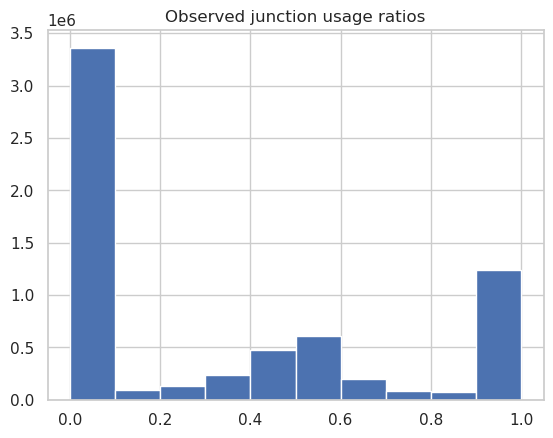

In [29]:
junc_ratios = final_data.juncratio
junc_ratios.hist()
# add title that says these are the observed junction usage ratios 
plt.title("Observed junction usage ratios")

In [30]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,0.0,4
1,0,1,2.0,4
2,0,2,9.0,4
3,0,3,1.0,4
4,0,4,3.0,4


In [31]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,17.0,22,5.0,0.772727,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,Brain_Non-Myeloid_endothelial_cell,1_7089216_7120193,14,0,0.0,4
1,5993,0,1.0,14,13.0,0.071429,N5-MAA000604-3_10_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,0.0,1
2,5951,0,8.0,37,29.0,0.216216,N3-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,4.0,1
3,5942,0,1.0,1,0.0,1.000000,N22-MAA000573-3_9_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,0.0,1
4,5885,0,21.0,76,55.0,0.276316,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,2.0,1


### Prep simulated data as input into mixture model

In [32]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,junction_id_index,junc_count,new_cell_type
0,0,22,5.0,0.772727,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,Brain_Non-Myeloid_endothelial_cell,1_7089216_7120193,14,0,0.0,4
1,5993,14,13.0,0.071429,N5-MAA000604-3_10_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,0.0,1
2,5951,37,29.0,0.216216,N3-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,4.0,1
3,5942,1,0.0,1.000000,N22-MAA000573-3_9_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,0.0,1
4,5885,76,55.0,0.276316,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_7089216_7120193,14,0,2.0,1


In [33]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

In [34]:
print(len(sim_data.Cluster.unique()))
print(len(sim_data.cell_id_index.unique()))

3613
7816


Text(0.5, 1.0, 'Simulated junction usage ratios')

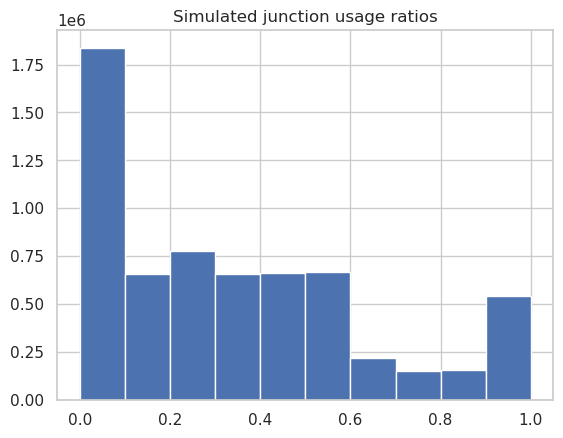

In [35]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]
sim_data.junc_ratio.hist()
# add title saying these are observed junction usage ratios
plt.title("Simulated junction usage ratios")

In [36]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


### Check how well the data is simulated, is there cell type specific splicing?

In [37]:
clust_labels_only = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()

In [38]:
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,14,Brain_Non-Myeloid_endothelial_cell,0,0.000000,0.0,23.0,negative
1,0,14,Brain_Non-Myeloid_endothelial_cell,1,0.086957,2.0,23.0,negative
2,0,14,Brain_Non-Myeloid_endothelial_cell,4363,0.913043,21.0,23.0,negative
3,5993,14,Brain_Myeloid_microglial_cell,0,0.000000,0.0,13.0,negative
4,5993,14,Brain_Myeloid_microglial_cell,1,0.076923,1.0,13.0,negative


Brain_Non-Myeloid_oligodendrocyte                   1707
Brain_Myeloid_microglial_cell                       1440
Brain_Non-Myeloid_endothelial_cell                   681
Brain_Non-Myeloid_neuron                             564
Brain_Non-Myeloid_astrocyte                          384
Brain_Non-Myeloid_oligodendrocyte_precursor_cell     267
Brain_Non-Myeloid_brain_pericyte                     210
Brain_Myeloid_macrophage                              63
Name: cell_type, dtype: int64


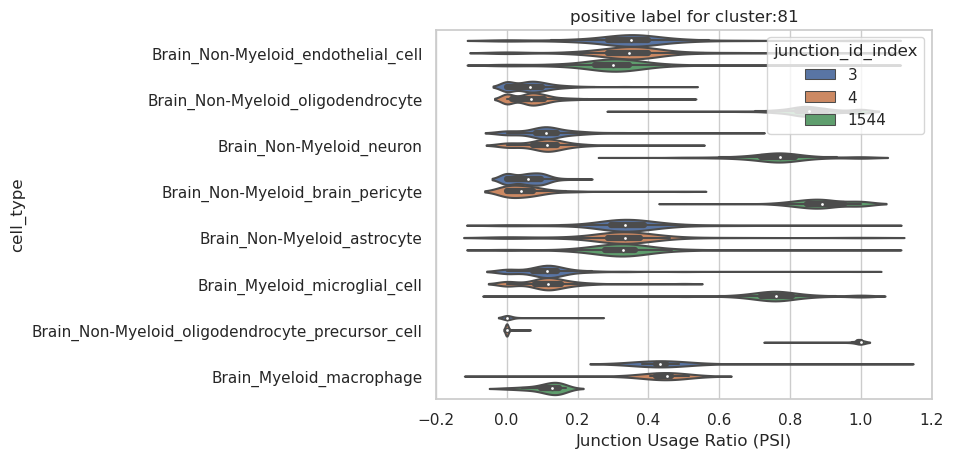

In [39]:
# let's visualize junction usage ratios for a given custer 
clust = 81
quick_clust_plot(clust, simple_data)

### Run mixture model

In [40]:
# make new cell_ids_conversion dataframe using new cell type column
cell_ids_conversion_new = sim_data[["cell_id_index", "cell_type", "cell_id", "new_cell_type"]].drop_duplicates()
cell_ids_conversion_new.head()

,cell_id_index,cell_type,cell_id,new_cell_type
0,0,Brain_Non-Myeloid_endothelial_cell,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,4
3,5993,Brain_Myeloid_microglial_cell,N5-MAA000604-3_10_M-1-1_Brain_Myeloid_microgli...,1
6,5951,Brain_Myeloid_microglial_cell,N3-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,1
9,5942,Brain_Myeloid_microglial_cell,N22-MAA000573-3_9_M-1-1_Brain_Myeloid_microgli...,1
12,5885,Brain_Myeloid_microglial_cell,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,1


In [41]:
# set random seed
torch.manual_seed(0)

num_trials = 50 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in
K = 50

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 7816 cells and J = 10839 junctions
Got the initial ELBO ^
ELBO converged @ -143746992.0 CAVI iteration # 14 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 7816 cells and J = 10839 junctions
Got the initial ELBO ^
ELBO converged @ -143813200.0 CAVI iteration # 38 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 7816 cells and J = 10839 junctions
Got the initial ELBO ^
ELBO converged @ -143746080.0 CAVI iteration # 38 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 7816 cells and J = 10839 junctions
Got the initial ELBO ^
ELBO converged @ -143761152.0 CAVI iteration # 16 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 7816 cells and J = 10839 junctions
Got the initial ELBO ^
ELBO converged @ -143762096.0 CAVI iteration # 43 complete
Finished CAVI!
Initialize

The trial with the highest ELBO was 23


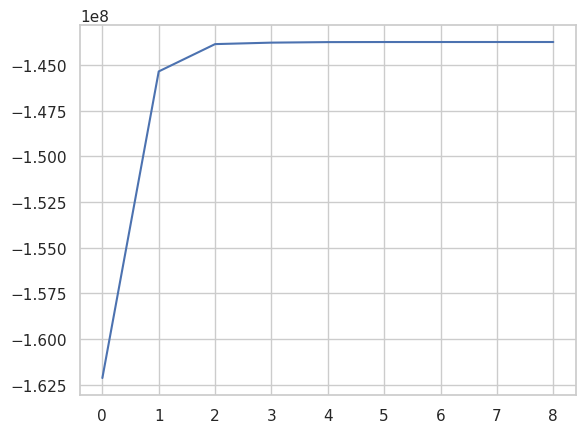

In [42]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

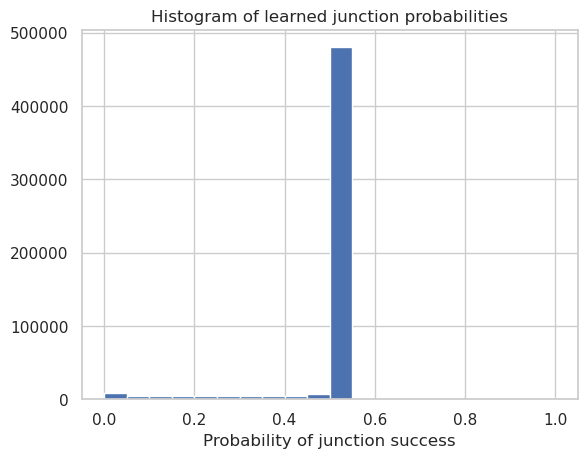

In [43]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
 
plt.hist(juncs_probs.cpu().numpy().flatten(), 20)
plt.title('Histogram of learned junction probabilities') 
plt.xlabel('Probability of junction success')
plt.show()

In [44]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()
# count number of times each cell type is assigned to each cell state
PHI_f_plot.groupby("cell_id").sum()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
cell_id,,,,,,,,,,,,,,,,,,,,,
Brain_Myeloid_macrophage,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Brain_Myeloid_microglial_cell,8.889685e-35,8.889685e-35,4.915841e-10,8.889685e-35,7.763942e-10,8.889685e-35,8.889685e-35,1.692575e-10,8.889685e-35,8.889685e-35,...,8.889685e-35,1.041616e-02,4.387976e+03,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35
Brain_Non-Myeloid_astrocyte,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,4.310000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Brain_Non-Myeloid_brain_pericyte,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.560000e+02,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Brain_Non-Myeloid_endothelial_cell,0.000000e+00,0.000000e+00,7.150000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Brain_Non-Myeloid_neuron,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.810000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Brain_Non-Myeloid_oligodendrocyte,0.000000e+00,0.000000e+00,9.997693e-04,0.000000e+00,2.318714e-04,0.000000e+00,0.000000e+00,1.258647e-08,0.000000e+00,0.000000e+00,...,0.000000e+00,7.276288e-09,1.455788e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [45]:
cell_ids_conversion_new.sort_values(by = ["cell_id_index"], inplace = True)
cell_ids_conversion_new.head()
# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion_new['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_types = cell_ids_conversion_new.new_cell_type.values
# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

In [46]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col) for col in juncs_probs_df.columns]
juncs_probs_df["new_junction_id_index"] = junction_ids_conversion.new_junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [47]:
cluster_labels.index = cluster_labels.new_junction_id_index.values
juncs_probs_df["sample_label"] = cluster_labels["sample_label"]
juncs_probs_df.head()

,cell_state_0,cell_state_1,cell_state_2,cell_state_3,cell_state_4,cell_state_5,cell_state_6,cell_state_7,cell_state_8,cell_state_9,...,cell_state_43,cell_state_44,cell_state_45,cell_state_46,cell_state_47,cell_state_48,cell_state_49,new_junction_id_index,junction_id,sample_label
0,0.5,0.5,0.074072,0.5,0.457471,0.5,0.5,0.153137,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0,1_7089216_7120193,negative
1,0.5,0.5,0.073217,0.5,0.452874,0.5,0.5,0.134686,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,1,1_7120615_7147636,negative
2,0.5,0.5,0.988808,0.5,0.863574,0.5,0.5,0.278459,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,2,1_7163371_7169514,positive
3,0.5,0.5,0.348175,0.5,0.115210,0.5,0.5,0.066732,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,3,1_37890584_37892942,positive
4,0.5,0.5,0.351539,0.5,0.114943,0.5,0.5,0.065089,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,4,1_37893023_37893938,positive


In [48]:
scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["new_junction_id_index"] = junction_ids_conversion.new_junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test = scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).new_junction_id_index.values

In [49]:
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

,score,new_junction_id_index
289,230363.359375,289
1362,138471.562500,1362
4048,107617.968750,4048
3764,106907.507812,3764
5241,90136.921875,5241
5240,89817.921875,5240
2443,86103.570312,2443
682,84240.281250,682
683,81970.039062,683
7868,73704.851562,7868


In [50]:
junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == 1663]

,junction_id_index,junction_id,Cluster,new_junction_id_index
1663,10837,16_18411957_18426355,18497,1663


Brain_Myeloid_microglial_cell                       9225
Brain_Non-Myeloid_oligodendrocyte                   2178
Brain_Non-Myeloid_endothelial_cell                   642
Brain_Non-Myeloid_neuron                             534
Brain_Non-Myeloid_astrocyte                          504
Brain_Non-Myeloid_oligodendrocyte_precursor_cell     375
Brain_Non-Myeloid_brain_pericyte                     315
Brain_Myeloid_macrophage                              90
Name: cell_type, dtype: int64


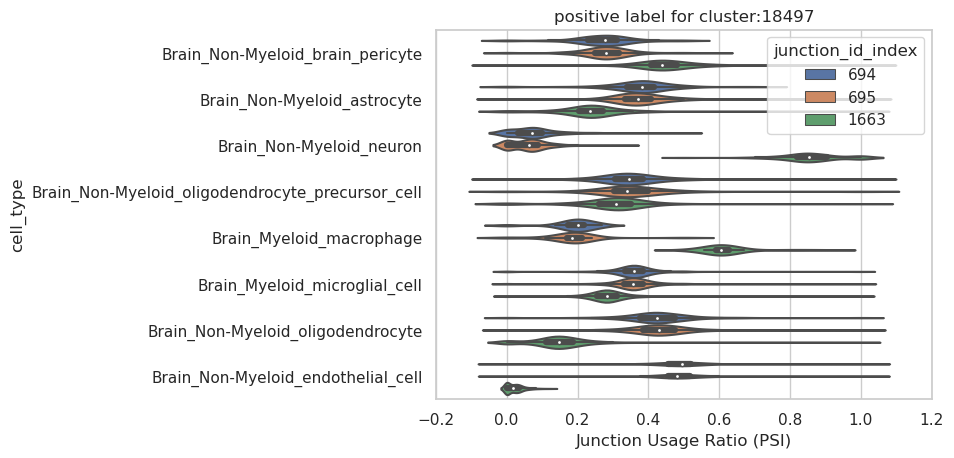

In [51]:
quick_clust_plot(18497, simple_data)

In [52]:
# for each junction get total sum of junc_count and also report gene_id 
sum_junc_counts = sim_data.groupby(["junction_id_index"]).agg({"junc_count": "sum"}).reset_index()
sum_junc_counts.sort_values(by = ["junction_id_index"], ascending = True, inplace = True)

In [53]:
sum_junc_counts["score"] = scores_all_juncs_df["score"]
sum_junc_counts.head()

,junction_id_index,junc_count,score
0,0,4283.0,1537.332031
1,1,4256.0,1486.900391
2,2,16609.0,12600.987305
3,3,14304.0,4151.269531
4,4,14315.0,4255.242188


In [54]:
sim_data["new_cell_type"] = sim_data["new_cell_type"].astype(str)

     junction_id_index        junction_id  Cluster  new_junction_id_index
289               2167  7_3705919_3706650     8030                    289


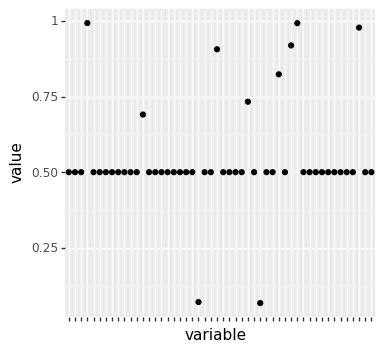


      junction_id_index           junction_id  Cluster  new_junction_id_index
1362               9236  13_58395687_58396826    16153                   1362


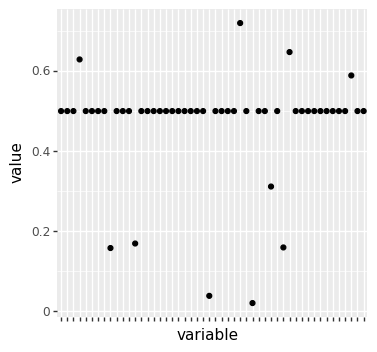

In [55]:
# for each junction in top10juncs_state1, run plot_juncObsUsage and plot_juncProbs
for junc in juncs_test:
    plot_juncProbs(junc)

In [56]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion_new.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion_new.new_cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_39445/4122663987.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_0,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,...,CellState_40,CellState_41,CellState_42,CellState_43,CellState_44,CellState_45,CellState_46,CellState_47,CellState_48,CellState_49
cell_type,,,,,,,,,,,,,,,,,,,,,
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,8.889685e-35,8.889685e-35,4.915841e-10,8.889685e-35,7.763942e-10,8.889685e-35,8.889685e-35,1.692575e-10,8.889685e-35,8.889685e-35,...,8.889685e-35,1.041616e-02,4.387976e+03,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35,8.889685e-35
2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,4.310000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.560000e+02,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,0.000000e+00,0.000000e+00,7.150000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.810000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,0.000000e+00,0.000000e+00,9.997693e-04,0.000000e+00,2.318714e-04,0.000000e+00,0.000000e+00,1.258647e-08,0.000000e+00,0.000000e+00,...,0.000000e+00,7.276288e-09,1.455788e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


/scratch/ipykernel_39445/1592633849.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_39445/1592633849.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


<Axes: ylabel='cell_type'>

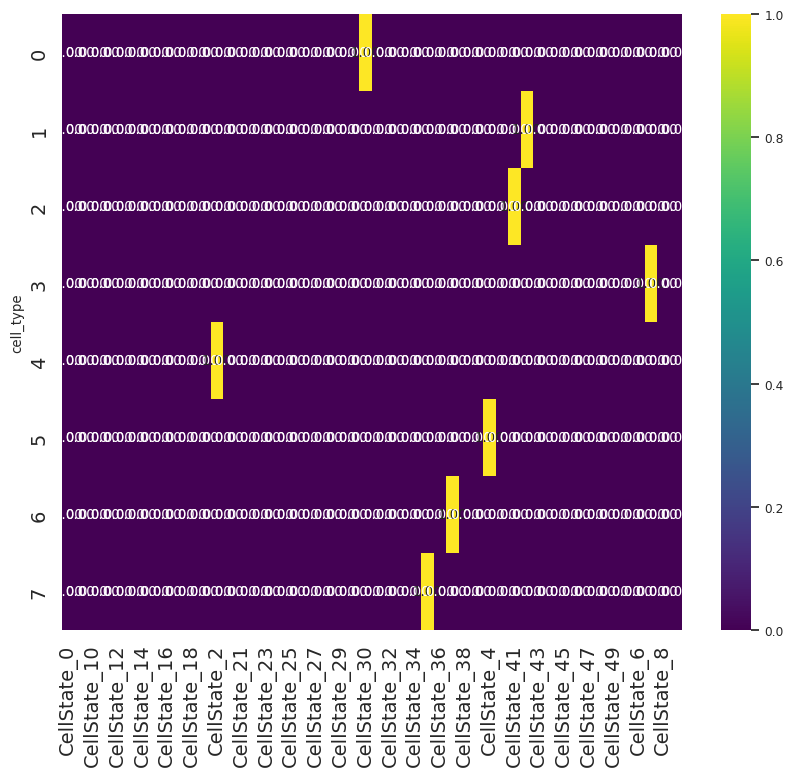

In [57]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(10, 8))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
sns.heatmap(sum_prop, annot=True, fmt=".2f", cmap='viridis')

## Consensus clustering 

In [58]:
num_trials = len(results)
N = results[0][3].shape[0]
all_iters_PHI_f = [ result[3] for result in results ]
i = 0

In [59]:
dfs_list = []
    
for PHI_var in all_iters_PHI_f:
    probability_tensor = PHI_var
    # Create an array with cell IDs (e.g., cell_0, cell_1, ..., cell_(N-1))
    cell_ids = np.arange(probability_tensor.shape[0])
    cell_ids = [cell_id for cell_id in cell_ids]
    # Get the cluster IDs for each cell based on the maximum probability
    cluster_ids = np.argmax(probability_tensor, axis=1)
    # Create a DataFrame with the cell_id, cluster_id, and probability columns
    df = pd.DataFrame({"cell_id": cell_ids, "cluster_id": cluster_ids})
    # Add column with iteration number
    df["iteration"] = i
    i += 1
    # Append the DataFrame to the list
    dfs_list.append(df)

# Concatenate all the DataFrames into a single DataFrame
concatenated_df = pd.concat(dfs_list, ignore_index=True)
print("Got all cells and their assignments based on PHI_f in each trial!")
# initiate list to save results for each iteration

all_iters_results = [None] * num_trials
for trial in range(num_trials):
    cell_by_cell_matrix = np.zeros((N, N))
    clusters = concatenated_df.loc[concatenated_df["iteration"] == trial, ["cell_id", "cluster_id"]]
    unique_clusters = clusters.set_index('cell_id')['cluster_id'].to_dict()
    # Fill the cell_by_cell_matrix using numpy indexing
    for cell_id, cluster_id in unique_clusters.items():
        cell_by_cell_matrix[cell_id, cell_id] = 1
        same_cluster_cells = clusters[clusters["cluster_id"] ==  cluster_id].cell_id.values
        cell_by_cell_matrix[cell_id, same_cluster_cells] = 1
    all_iters_results[trial] = cell_by_cell_matrix
# get all pairs of num_trials 
print("Got a cell by cell matrix for each trial indicating whether cells were coassigned")
# Calculate sum over matrices across all iterations to find cell-cell pairs that are MOST misassigned 
print("Getting sum of matrices across all iterations")
sum_matrices = sum(all_iters_results)
sum_matrices

Got all cells and their assignments based on PHI_f in each trial!
Got a cell by cell matrix for each trial indicating whether cells were coassigned
Getting sum of matrices across all iterations


array([[50., 50., 50., ...,  0.,  0.,  0.],
       [50., 50., 50., ...,  0.,  0.,  0.],
       [50., 50., 50., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., 50., 46., 47.],
       [ 0.,  0.,  0., ..., 46., 50., 43.],
       [ 0.,  0.,  0., ..., 47., 43., 50.]])

In [60]:
sum_matrices

array([[50., 50., 50., ...,  0.,  0.,  0.],
       [50., 50., 50., ...,  0.,  0.,  0.],
       [50., 50., 50., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., 50., 46., 47.],
       [ 0.,  0.,  0., ..., 46., 50., 43.],
       [ 0.,  0.,  0., ..., 47., 43., 50.]])

In [61]:
cell_ids_conversion.shape

(7816, 3)

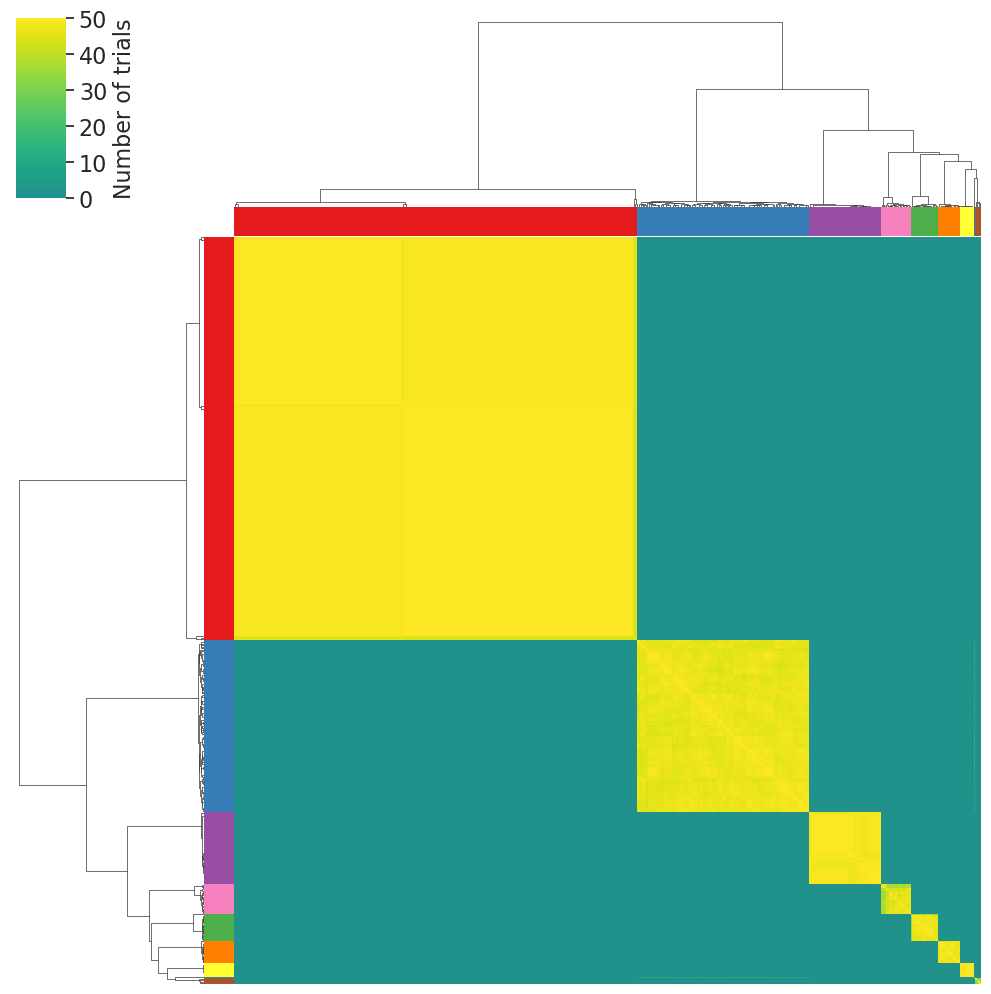

In [62]:
samp_indices = np.random.choice(cell_ids_conversion.shape[0], 500, replace=False)
cell_types_heatmap = cell_ids_conversion.iloc[samp_indices]

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))

# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_heatmap['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_heatmap.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=sum_matrices[samp_indices,:][:,samp_indices],
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    xticklabels=False,
    yticklabels=False,
    figsize=(10, 10),
    center=0,
    row_colors=row_colors,  # Apply row colors
    col_colors=col_colors,   # Apply column colors
        cbar_kws={'label': 'Number of trials'} # Split label over two lines here
    )
cluster.cax.set_ylabel('Number of trials', size=16)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(16)

plt.show()

In [63]:
# cluster the matrix
sum_matrices

array([[50., 50., 50., ...,  0.,  0.,  0.],
       [50., 50., 50., ...,  0.,  0.,  0.],
       [50., 50., 50., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., 50., 46., 47.],
       [ 0.,  0.,  0., ..., 46., 50., 43.],
       [ 0.,  0.,  0., ..., 47., 43., 50.]])

In [87]:
sum_matrices.shape

(7816, 7816)

In [81]:
# Hierarchical clustering for rows and columns
row_linkage = linkage(sum_matrices, method='complete')
col_linkage = linkage(sum_matrices.T, method='complete')

In [91]:
# Cut dendrograms to get cluster assignments
k = 50  # Number of desired clusters
row_clusters = fcluster(row_linkage, k, criterion='maxclust')
col_clusters = fcluster(col_linkage, k, criterion='maxclust')

In [92]:
from sklearn.metrics import adjusted_rand_score

# Assuming row_clusters and col_clusters are computed as previously shown
ari_comparison = adjusted_rand_score(row_clusters, col_clusters)

print("Adjusted Rand Score between row and column clusterings:", ari_comparison)

Adjusted Rand Score between row and column clusterings: 1.0


In [93]:
row_clusters

array([28, 28, 28, ..., 41, 41, 41], dtype=int32)

In [94]:
col_clusters

array([28, 28, 28, ..., 41, 41, 41], dtype=int32)

In [64]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Convert similarity matrix to distance matrix
max_value = np.max(sum_matrices)
distance_matrix = max_value - sum_matrices
condensed_distance_matrix = squareform(distance_matrix)
Z = linkage(condensed_distance_matrix, method='complete')

In [65]:
# Extract 8 clusters
clusters = fcluster(Z, t=8, criterion='maxclust')

print(clusters)

[7 7 7 ... 1 1 1]


In [ ]:
# now get clusters for 

In [76]:
len(clusters)

7816

In [78]:
cell_ids_conversion_new["coassignment_cluster"] = clusters
cell_ids_conversion_new.head()

,cell_id_index,cell_type,cell_id,new_cell_type,coassignment_cluster
0,0,Brain_Non-Myeloid_endothelial_cell,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,4,7
2454,1,Brain_Non-Myeloid_endothelial_cell,A1-MAA000932-3_11_M-1-1_Brain_Non-Myeloid_endo...,4,7
41508,2,Brain_Non-Myeloid_endothelial_cell,A1-MAA001894-3_39_F-1-1_Brain_Non-Myeloid_endo...,4,7
10353,3,Brain_Non-Myeloid_endothelial_cell,A1-MAA001895-3_38_F-1-1_Brain_Non-Myeloid_endo...,4,7
62571,4,Brain_Non-Myeloid_endothelial_cell,A10-B003290-3_38_F-1-1_Brain_Non-Myeloid_endot...,4,7


In [80]:
cell_ids_conversion_new.groupby("coassignment_cluster").count()

,cell_id_index,cell_type,cell_id,new_cell_type
coassignment_cluster,,,,
1,281,281,281,281
2,156,156,156,156
3,432,432,432,432
4,203,203,203,203
5,61,61,61,61
6,4394,4394,4394,4394
7,715,715,715,715
8,1574,1574,1574,1574


In [79]:
# calcualte ARI between coassignment_cluster and new_cell_type
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(cell_ids_conversion_new["new_cell_type"], cell_ids_conversion_new["coassignment_cluster"])

1.0

In [66]:
# normalize by number of trials
normalized_matrix = sum_matrices / sum_matrices.max() # taking the sum_matrix and dividing by the max value in the matrix

# get distance metric 
distance_matrix = 1 - normalized_matrix
distance_matrix

array([[0.  , 0.  , 0.  , ..., 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , ..., 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , ..., 1.  , 1.  , 1.  ],
       ...,
       [1.  , 1.  , 1.  , ..., 0.  , 0.08, 0.06],
       [1.  , 1.  , 1.  , ..., 0.08, 0.  , 0.14],
       [1.  , 1.  , 1.  , ..., 0.06, 0.14, 0.  ]])

In [67]:
# cluster distance matrix using hierarchical clustering into K clusters 
from sklearn.cluster import KMeans
# Number of clusters
num_clusters = 9

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters)
cluster_labels = kmeans.fit_predict(distance_matrix)

# Your N by K matrix
n_by_k_matrix = np.zeros((distance_matrix.shape[0], num_clusters))

# Fill the N by K matrix with cluster assignments
for i in range(num_clusters):
    n_by_k_matrix[:, i] = (cluster_labels == i).astype(int)

In [68]:
# sample 5200 indices from distance matrix
samp_indices = np.random.choice(cell_ids_conversion_new.shape[0], 5200, replace=False)
cell_types_heatmap = cell_ids_conversion_new.iloc[samp_indices]

In [69]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))

# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_heatmap['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_types = cell_types_heatmap.cell_type.values

# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

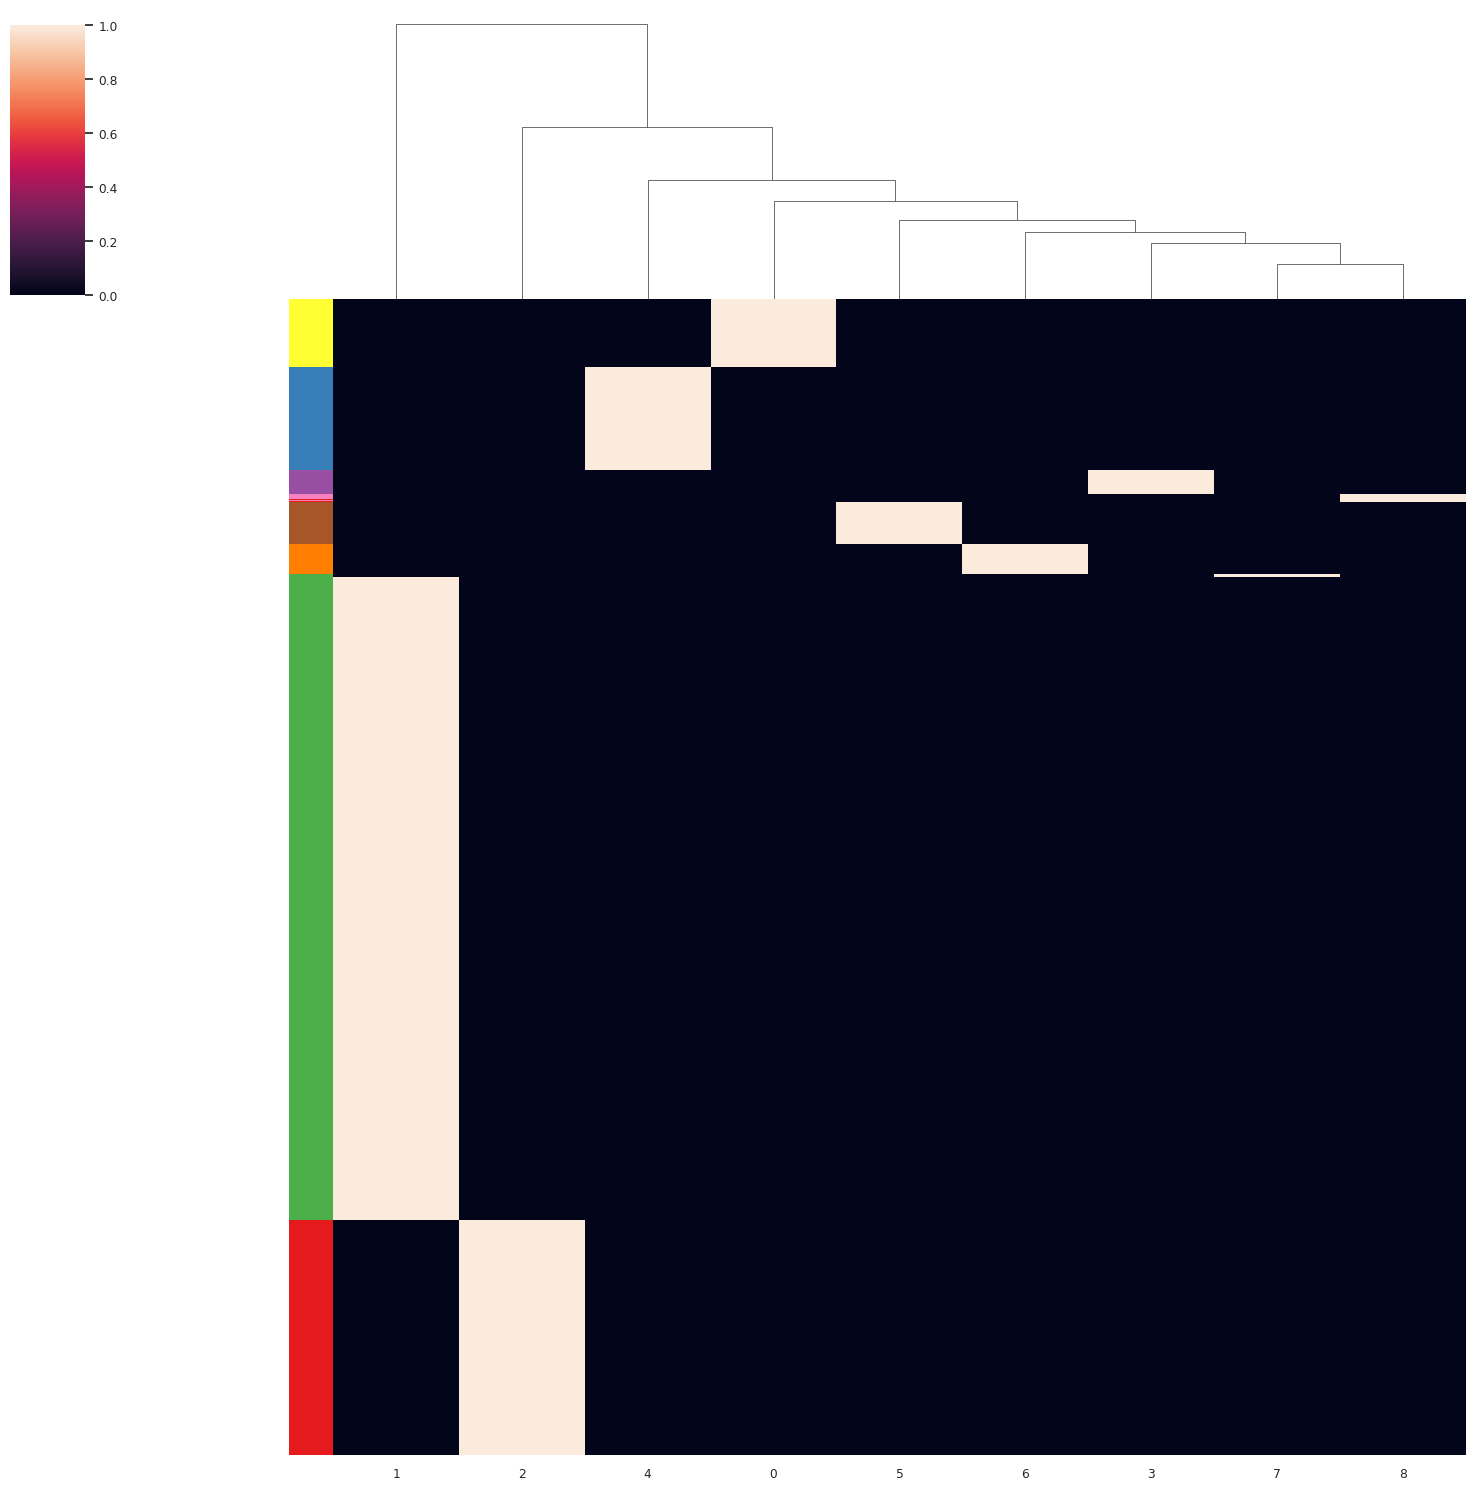

In [70]:
# draw clustermap of sampled_distance_matrix
# Create a clustermap with row colors representing cell types

clustmap = sns.clustermap(
    data=n_by_k_matrix[samp_indices,:],
    annot=False,
    fmt=".2f",
    xticklabels=True,
    yticklabels=False,
    row_colors=row_colors, 
    figsize=(15, 15))

clustmap.ax_row_dendrogram.set_visible(False)

# Show the plot
plt.show()

In [71]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot.head()

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())

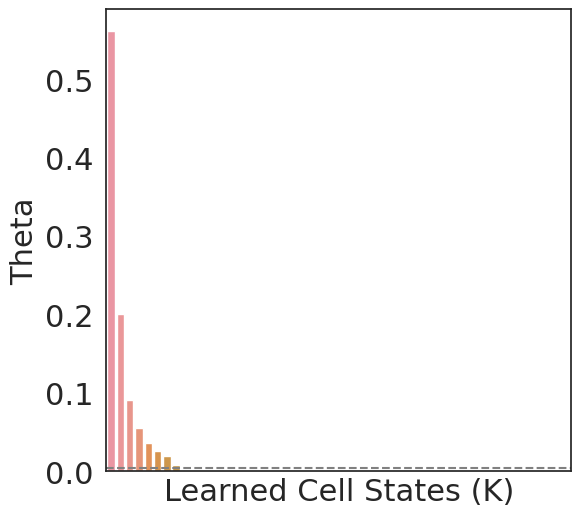

In [72]:
# make barplot using sns.
plt.figure(figsize=(6, 6))
sns.set_style("white")
plt.axhline(0.005, ls='--', color='grey')
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot)
# make Y lab say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=22)
plt.xlabel("Learned Cell States (K)", fontsize=22)
# remove xaxis ticks
plt.xticks([])
plt.yticks(fontsize=22)
# make background white
plt.show()

In [73]:
cluster_labels

array([4, 4, 4, ..., 5, 5, 5], dtype=int32)

In [74]:
# calculate jaccard index for n_by_k_matrix and true cell type labels 
from sklearn.metrics import jaccard_score
# get true cell type labels for each cell
true_cell_types = cell_ids_conversion_new["new_cell_type"].values
# calculate jaccard index for each cell type
jaccard = jaccard_score(true_cell_types, cluster_labels, average='weighted')
print("Jaccard Index:", jaccard)

Jaccard Index: 0.7053480040941658


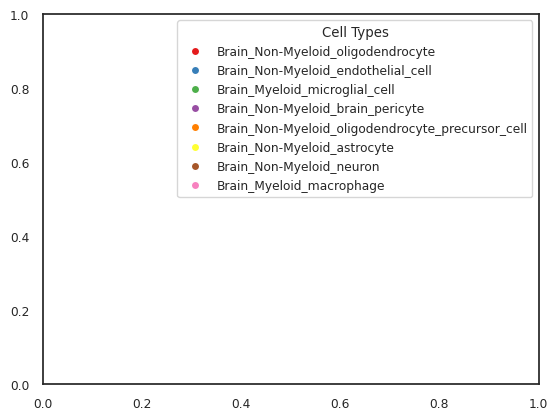

In [75]:
# Add a custom legend for row cell types
legend_labels = cell_type_colors.keys()
legend_colors = cell_type_colors.values()
custom_legend = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=6, markerfacecolor=color) for label, color in zip(legend_labels, legend_colors)]
plt.legend(handles=custom_legend, title='Cell Types')